In [2]:
# Verify installations
import shap
import qiskit_aer
print(f"SHAP version: {shap.__version__}")
print(f"Qiskit Aer version: {qiskit_aer.__version__}")
print("All packages ready.")

c:\Users\Hridi\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.52.0
Qiskit Aer version: 0.17.2
All packages ready.


In [3]:
# CELL 2: SETUP saved .npy files

import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 13})
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Load saved .npy files
svm_mean_proba    = np.load('svm_mean_proba.npy')
qsvm_mean_proba   = np.load('qsvm_mean_proba.npy')
ensemble_proba    = np.load('ensemble_proba.npy')
ensemble_pred     = np.load('ensemble_final_pred.npy')
y_test            = np.load('y_test.npy')
svm_proba_matrix  = np.load('svm_proba_matrix.npy')
qsvm_proba_matrix = np.load('qsvm_proba_matrix.npy')

svm_soft_pred  = (svm_mean_proba  >= 0.5).astype(int)
qsvm_soft_pred = (qsvm_mean_proba >= 0.5).astype(int)
y_true = y_test

# Rebuild dataset and preprocessing
df = pd.read_csv("email_phishing_dataset_FINAL.csv")
df = df.dropna(subset=['email_from_domain'])
df['domain_age_missing'] = df['domain_age'].isnull().astype(int)
df['domain_age'] = df['domain_age'].fillna(0)

df_encoded = df.copy()

# Frequency encoding
domain_freq = df_encoded['email_from_domain'].value_counts(normalize=True)
df_encoded['email_domain_freq'] = (df_encoded['email_from_domain']
                                    .map(domain_freq).fillna(0))
df_encoded.drop(['email_from_domain'], axis=1, inplace=True)

geo_freq = df_encoded['web_geo_loc'].value_counts(normalize=True)
df_encoded['web_geo_loc'] = df_encoded['web_geo_loc'].map(geo_freq).fillna(0)

# Binary encodings
trusted_tlds = ['com', 'org', 'net', 'edu', 'gov']
df_encoded['web_tld'] = df_encoded['web_tld'].apply(
    lambda x: 1.0 if str(x).lower() in trusted_tlds else 0.0
)
df_encoded['web_who_is'] = (df_encoded['web_who_is'] == 'complete').astype(int)
df_encoded['web_https']  = (df_encoded['web_https']  == 'yes').astype(int)

# Drop raw text columns
for col in ['web_url', 'web_ip_add', 'web_content']:
    if col in df_encoded.columns:
        df_encoded.drop(col, axis=1, inplace=True)

# Split + scale 
X = df_encoded.drop('final_label', axis=1)
y = df_encoded['final_label']

X_train, X_test_df, y_train, y_test_df = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_df), columns=X_test_df.columns
)

# Feature selection 
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=42)
mi_df = pd.DataFrame({
    'feature':  X_train.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

top_features = mi_df.head(6)['feature'].tolist()
X_train_selected = X_train_scaled[top_features]
X_test_selected  = X_test_scaled[top_features]

print("Setup complete.")
print(f"Top 6 features: {top_features}")

# Train surrogate SVM used for SHAP... trained on all training data at once for a stable explainer
surrogate_svm = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42,
    probability=True    # needed for SHAP predict_proba
)
surrogate_svm.fit(X_train_selected, y_train)
surr_acc = accuracy_score(y_test_df, surrogate_svm.predict(X_test_selected))
print(f"Surrogate SVM accuracy (full training set): {surr_acc:.4f}")




Setup complete.
Top 6 features: ['web_js_len', 'js_obfuscation_ratio', 'web_js_obf_len', 'content_num_scripts', 'content_entropy', 'domain_trust_score']
Surrogate SVM accuracy (full training set): 0.9923


Initialising KernelExplainer...
Computing SHAP values for 200 test samples...


100%|██████████| 200/200 [00:28<00:00,  6.92it/s]


SHAP values computed. Shape: (200, 6)
SHAP values per feature (mean absolute):
  web_js_len                     0.2060
  js_obfuscation_ratio           0.1268
  web_js_obf_len                 0.0617
  content_num_scripts            0.0295
  content_entropy                0.0495
  domain_trust_score             0.0404


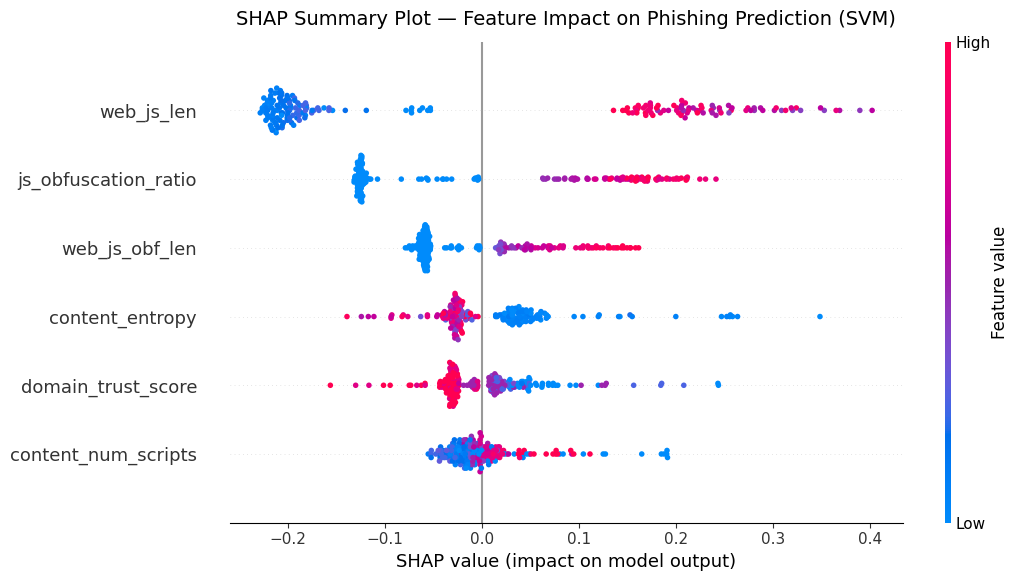

Saved: shap_beeswarm.png


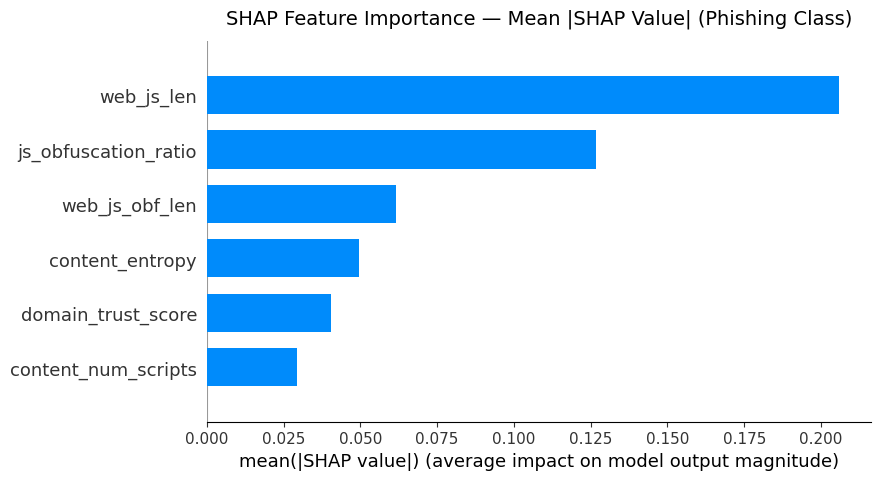

Saved: shap_bar.png

SHAP Feature Importance Table:
 Rank              Feature  Mean |SHAP|
    1           web_js_len     0.205970
    2 js_obfuscation_ratio     0.126814
    3       web_js_obf_len     0.061661
    4      content_entropy     0.049478
    5   domain_trust_score     0.040448
    6  content_num_scripts     0.029517
Saved: shap_importance_table.csv
Saved: shap_values_phishing.npy


In [4]:

# CELL 3: SHAP ANALYSIS

feature_names = [
    'web_js_len',
    'js_obfuscation_ratio',
    'web_js_obf_len',
    'content_num_scripts',
    'content_entropy',
    'domain_trust_score'
]

# Background sample: 100 random training instances 

background = shap.sample(X_train_selected, 100, random_state=42)

print("Initialising KernelExplainer...")
explainer = shap.KernelExplainer(
    surrogate_svm.predict_proba,   # returns [P(class0), P(class1)]
    background
)


# nsamples=150 controls approximation quality... higher = slower but more accurate
print("Computing SHAP values for 200 test samples...")

shap_values = explainer.shap_values(
    X_test_selected.iloc[:200],
    nsamples=150
)


# class 1 (phishing) 
shap_phishing = shap_values[:, :, 1]

print(f"SHAP values computed. Shape: {shap_phishing.shape}")
print("SHAP values per feature (mean absolute):")
for i, feat in enumerate(feature_names):
    print(f"  {feat:<30} {np.abs(shap_phishing[:, i]).mean():.4f}")




# Plot 1: SHAP Beeswarm Summary Plot

plt.figure(figsize=(11, 6))
shap.summary_plot(
    shap_phishing,
    X_test_selected.iloc[:200].values,
    feature_names=feature_names,
    show=False,
    plot_size=(11, 6),
    max_display=6
)
plt.title(
    "SHAP Summary Plot — Feature Impact on Phishing Prediction (SVM)",
    fontsize=14, pad=12
)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved: shap_beeswarm.png")


# Plot 2: SHAP Bar Plot (Mean |SHAP|) 
# Shows global feature importance ranked by average absolute SHAP value
plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_phishing,
    X_test_selected.iloc[:200].values,
    feature_names=feature_names,
    plot_type='bar',
    show=False,
    plot_size=(9, 5),
    max_display=6
)
plt.title(
    "SHAP Feature Importance — Mean |SHAP Value| (Phishing Class)",
    fontsize=14, pad=12
)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved: shap_bar.png")


# Table: SHAP Feature Importance
shap_importance = pd.DataFrame({
    'Rank':        range(1, 7),
    'Feature':     feature_names,
    'Mean |SHAP|': np.abs(shap_phishing).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
shap_importance['Rank'] = range(1, 7)

print("\nSHAP Feature Importance Table:")
print(shap_importance.to_string(index=False))
shap_importance.to_csv('shap_importance_table.csv', index=False)
print("Saved: shap_importance_table.csv")


np.save('shap_values_phishing.npy', shap_phishing)
print("Saved: shap_values_phishing.npy")


